In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [17]:
md = pd.read_csv('spider_measurements.csv',header = None ,names=['abdomen-circumference', 'abdomen-length',
                             'pedipalp-length', 'chelicerae-length'])

spiders = pd.DataFrame(md)

spiders.columns


Index(['abdomen-circumference', 'abdomen-length', 'pedipalp-length',
       'chelicerae-length'],
      dtype='str')

In [18]:
spiders.head()

,abdomen-circumference,abdomen-length,pedipalp-length,chelicerae-length
0,5.1,3.5,1.4,0.02
1,4.9,3.0,1.4,0.02
2,4.7,3.2,1.3,0.02
3,4.6,3.1,1.5,0.02
4,5.0,3.6,1.4,0.02


In [19]:
spiders.describe()

,abdomen-circumference,abdomen-length,pedipalp-length,chelicerae-length
count,156.000000,156.000000,156.000000,156.000000
mean,8.169872,4.282692,5.191026,0.169103
std,11.788280,6.263969,8.036733,0.298621
min,4.300000,2.000000,1.000000,0.010000
25%,5.100000,2.800000,1.600000,0.030000
50%,5.800000,3.000000,4.400000,0.135000
75%,6.500000,3.400000,5.200000,0.190000
max,76.000000,42.000000,59.000000,2.300000


In [10]:
spiders.info()

<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   abdomen-circumference  155 non-null    float64
 1   abdomen-length         155 non-null    float64
 2   pedipalp-length        155 non-null    float64
 3   chelicerae-length      155 non-null    float64
dtypes: float64(4)
memory usage: 5.0 KB


In [11]:
spiders.isnull().sum()

abdomen-circumference    0
abdomen-length           0
pedipalp-length          0
chelicerae-length        0
dtype: int64

In [12]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
spiders_scaled = scaler.fit_transform(spiders)
spiders_scaled_df = pd.DataFrame(spiders_scaled, columns=spiders.columns)
print('Scaled feature summary (mean ≈ 0, std ≈ 1):')
spiders_scaled_df.describe().round(4)

Scaled feature summary (mean ≈ 0, std ≈ 1):


,abdomen-circumference,abdomen-length,pedipalp-length,chelicerae-length
count,155.0000,155.0000,155.0000,155.0000
mean,0.0000,0.0000,-0.0000,0.0000
std,1.0032,1.0032,1.0032,1.0032
min,-0.3300,-0.3652,-0.5249,-0.5364
25%,-0.2622,-0.2375,-0.4502,-0.4694
50%,-0.2028,-0.2056,-0.1015,-0.1008
75%,-0.1434,-0.1417,-0.0019,0.0668
max,5.7536,6.0208,6.6972,7.1383


In [13]:
spiders.dtypes

abdomen-circumference    float64
abdomen-length           float64
pedipalp-length          float64
chelicerae-length        float64
dtype: object

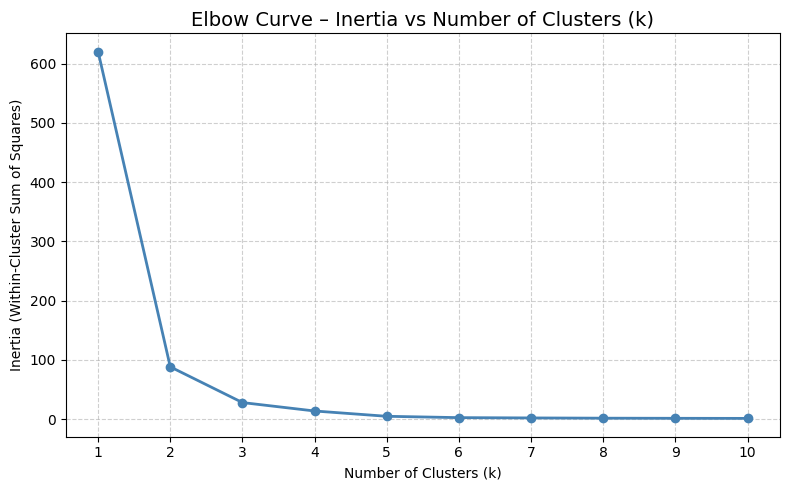

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_values = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(spiders_scaled)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', linewidth=2, color='steelblue')
plt.title('Elbow Curve – Inertia vs Number of Clusters (k)', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

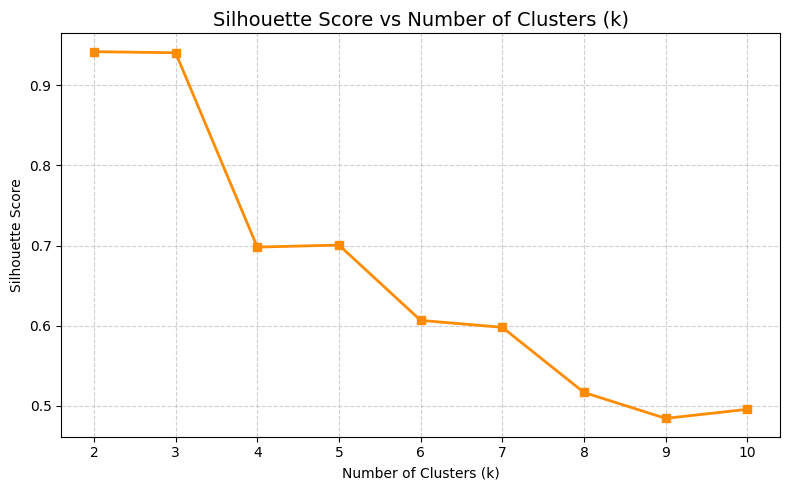

Best k by Silhouette Score: 2 (score = 0.9419)


In [15]:
silhouette_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(spiders_scaled)
    score = silhouette_score(spiders_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range_sil, silhouette_scores, marker='s', linewidth=2, color='darkorange')
plt.title('Silhouette Score vs Number of Clusters (k)', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range_sil)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

best_k_sil = k_range_sil[np.argmax(silhouette_scores)]
print(f'Best k by Silhouette Score: {best_k_sil} (score = {max(silhouette_scores):.4f})')

In [16]:
# Based on elbow and silhouette analysis, use optimal k
optimal_k = 2  # Adjust if your plots suggest a different value

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(spiders_scaled)

print('Cluster labels assigned to each data point:')
print(labels)
print(f'\nTotal labels: {len(labels)}')
print(f'Unique cluster labels: {np.unique(labels)}')

Cluster labels assigned to each data point:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1]

Total labels: 155
Unique cluster labels: [0 1]


In [22]:
# Apply PCA to reduce to 2 dimensions
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
spiders_pca = pca.fit_transform(spiders_scaled)

print(f'Dimensions BEFORE PCA transformation: {spiders_scaled.shape}')
print(f'Dimensions AFTER  PCA transformation: {spiders_pca.shape}')

Dimensions BEFORE PCA transformation: (155, 4)
Dimensions AFTER  PCA transformation: (155, 2)


In [23]:
# Principal components and explained variance
print('Principal Components (loadings):')
pc_df = pd.DataFrame(
    pca.components_,
    columns=spiders.columns,
    index=['PC1', 'PC2']
)
print(pc_df.round(4))
print()
print('Explained Variance Ratio per component:')
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f'  PC{i}: {var:.4f}  ({var*100:.2f}%)')
print(f'  Total variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%')

Principal Components (loadings):
     abdomen-circumference  abdomen-length  pedipalp-length  chelicerae-length
PC1                 0.5160          0.4793           0.5107             0.4931
PC2                 0.2493          0.6968          -0.3528            -0.5726

Explained Variance Ratio per component:
  PC1: 0.9189  (91.89%)
  PC2: 0.0797  (7.97%)
  Total variance explained: 99.86%


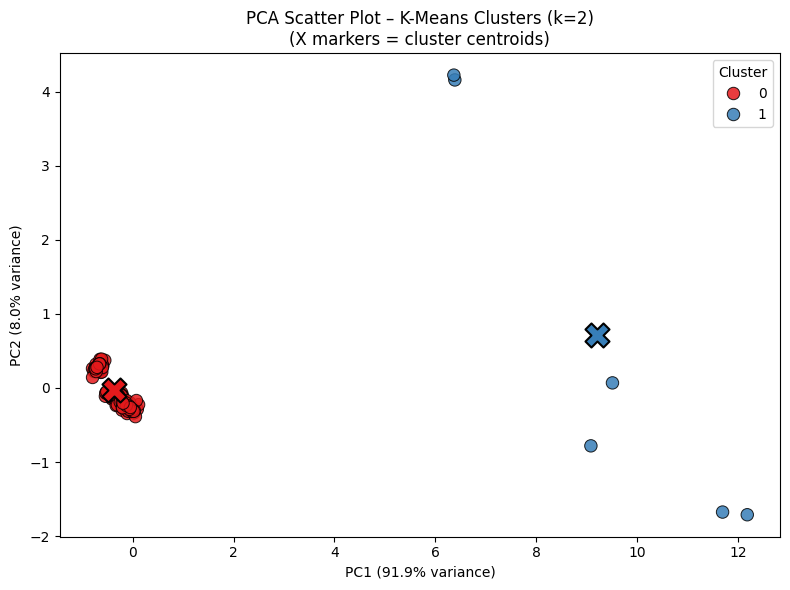

In [24]:
# Seaborn scatter plot of PCA components coloured by cluster
pca_plot_df = pd.DataFrame(spiders_pca, columns=['PC1', 'PC2'])
pca_plot_df['Cluster'] = labels.astype(str)

# Explicit colour palette — one colour per cluster
cluster_colours = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
palette = {str(i): cluster_colours[i] for i in range(optimal_k)}

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_plot_df, x='PC1', y='PC2',
    hue='Cluster', palette=palette,
    edgecolor='k', s=80, alpha=0.85
)

# Plot centroids transformed into PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    plt.scatter(cx, cy, c=cluster_colours[i], s=300, marker='X',
                edgecolors='black', linewidths=1.5, zorder=5)

plt.title(f'PCA Scatter Plot – K-Means Clusters (k={optimal_k})\n(X markers = cluster centroids)', fontsize=12)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()